##1-Nettoyage de la dataset/Data exploration

In [ ]:
#Importation de la dataset de HuggingFace
from datasets import load_dataset

dataset = load_dataset("jhan21/amazon-beauty-reviews-dataset", trust_remote_code=True)
print(dataset["train"])



`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'jhan21/amazon-beauty-reviews-dataset' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'jhan21/amazon-beauty-reviews-dataset' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart 

README.md: 0.00B [00:00, ?B/s]

amazon_beauty_reviews_dataset.csv:   0%|          | 0.00/232M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/701528 [00:00<?, ? examples/s]

Dataset({
    features: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase'],
    num_rows: 701528
})


In [ ]:
df = dataset["train"].to_pandas()
display(df.head())

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True


In [ ]:
print("Shape du dataset :", df.shape)

print("\nColonnes disponibles :")
print(df.columns.tolist())

print("\nAperçu des premières lignes :")
display(df.head())

Shape du dataset : (701528, 10)

Colonnes disponibles :
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

Aperçu des premières lignes :


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701528 entries, 0 to 701527
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   rating             701528 non-null  int64 
 1   title              701368 non-null  object
 2   text               701316 non-null  object
 3   images             701528 non-null  object
 4   asin               701528 non-null  object
 5   parent_asin        701528 non-null  object
 6   user_id            701528 non-null  object
 7   timestamp          701528 non-null  object
 8   helpful_vote       701528 non-null  int64 
 9   verified_purchase  701528 non-null  bool  
dtypes: bool(1), int64(2), object(7)
memory usage: 48.8+ MB


In [ ]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values

,0
text,212
title,160
rating,0
images,0
asin,0
parent_asin,0
user_id,0
timestamp,0
helpful_vote,0
verified_purchase,0


In [ ]:
#Les 10 features en question
print(df.columns)

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='object')


In [ ]:
# Colonnes qui vont etre gardés
cols = [
    "user_id",
    "asin",
    "parent_asin",
    "rating",
    "title",
    "text",
    "timestamp",
    "verified_purchase"
]

# On garde seulement les colonnes utiles
df_work = df[cols].copy()

# Vérification
print("Shape après sélection des colonnes :", df_work.shape)
display(df_work.head())

Shape après sélection des colonnes : (701528, 8)


,user_id,asin,parent_asin,rating,title,text,timestamp,verified_purchase
0,AGKHLEW2SOWHNMFQIJGBECAF7INQ,B00YQ6X8EO,B00YQ6X8EO,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,2020-05-05 14:08:48.923,True
1,AGKHLEW2SOWHNMFQIJGBECAF7INQ,B081TJ8YS3,B081TJ8YS3,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",2020-05-04 18:10:55.070,True
2,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,B07PNNCSP9,B097R46CSY,5,Yes!,"Smells good, feels great!",2020-05-16 21:41:06.052,True
3,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,B09JS339BZ,B09JS339BZ,1,Synthetic feeling,Felt synthetic,2022-01-28 18:13:50.220,True
4,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,B08BZ63GMJ,B08BZ63GMJ,5,A+,Love it,2020-12-30 10:02:43.534,True


In [ ]:
df_work["item_id"] = df_work["parent_asin"].fillna(df_work["asin"])

print("Nombre d'utilisateurs uniques :", df_work["user_id"].nunique())
print("Nombre d'items uniques :", df_work["item_id"].nunique())
print("Nombre de reviews :", len(df_work))

display(df_work[["user_id", "asin", "parent_asin", "item_id", "rating", "title", "text"]].head())

Nombre d'utilisateurs uniques : 631986
Nombre d'items uniques : 112565
Nombre de reviews : 701528


,user_id,asin,parent_asin,item_id,rating,title,text
0,AGKHLEW2SOWHNMFQIJGBECAF7INQ,B00YQ6X8EO,B00YQ6X8EO,B00YQ6X8EO,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...
1,AGKHLEW2SOWHNMFQIJGBECAF7INQ,B081TJ8YS3,B081TJ8YS3,B081TJ8YS3,4,Works great but smells a little weird.,"This product does what I need it to do, I just..."
2,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,B07PNNCSP9,B097R46CSY,B097R46CSY,5,Yes!,"Smells good, feels great!"
3,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,B09JS339BZ,B09JS339BZ,B09JS339BZ,1,Synthetic feeling,Felt synthetic
4,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,B08BZ63GMJ,B08BZ63GMJ,B08BZ63GMJ,5,A+,Love it


In [ ]:
missing_work = df_work.isna().sum().sort_values(ascending=False)
missing_work

,0
text,212
title,160
user_id,0
parent_asin,0
asin,0
rating,0
timestamp,0
verified_purchase,0
item_id,0


In [ ]:
df_work.shape
df_work.isna().sum()
df_work[["user_id", "item_id", "rating", "title", "text"]].head()

,user_id,item_id,rating,title,text
0,AGKHLEW2SOWHNMFQIJGBECAF7INQ,B00YQ6X8EO,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...
1,AGKHLEW2SOWHNMFQIJGBECAF7INQ,B081TJ8YS3,4,Works great but smells a little weird.,"This product does what I need it to do, I just..."
2,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,B097R46CSY,5,Yes!,"Smells good, feels great!"
3,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,B09JS339BZ,1,Synthetic feeling,Felt synthetic
4,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,B08BZ63GMJ,5,A+,Love it


In [ ]:
#On supprime chaque ligne ou y'a ni rating ni texte
df = df.dropna(subset=['rating', 'text'])

#On garde les colonnes utiles pour notre pipeline
df = df[['user_id','parent_asin','rating','title','text']]

#Créer la colonne full_text (qui contient tiltle + Text)
df["full_text"] = (
    df["title"].astype(str).str.strip()
    + ". "
    + df["text"].astype(str).str.strip()
)

df["full_text"] = df["full_text"].str.strip()


In [ ]:
#Ici, on vent garder le texte naturel pour le LLM. On ne fait pas de stemming, pas de suppression des stopwords, pas de tokenisation.

import re

def clean_review_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)   # remplace plusieurs espaces par un seul
    text = text.strip()
    return text

df["full_text"] = df["full_text"].apply(clean_review_text)

#Vérification

print("Shape finale après nettoyage :", df.shape)

display(df[["user_id", "parent_asin","rating", "title", "text", "full_text"]].head())

Shape finale après nettoyage : (701316, 6)


,user_id,parent_asin,rating,title,text,full_text
0,AGKHLEW2SOWHNMFQIJGBECAF7INQ,B00YQ6X8EO,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,Such a lovely scent but not overpowering.. Thi...
1,AGKHLEW2SOWHNMFQIJGBECAF7INQ,B081TJ8YS3,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",Works great but smells a little weird.. This p...
2,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,B097R46CSY,5,Yes!,"Smells good, feels great!","Yes!. Smells good, feels great!"
3,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,B09JS339BZ,1,Synthetic feeling,Felt synthetic,Synthetic feeling. Felt synthetic
4,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,B08BZ63GMJ,5,A+,Love it,A+. Love it


In [ ]:
#Testing de quelques exemples de reviews
for i in range(5):
    print("Review", i)
    print(df["full_text"].iloc[i])
    print("-" * 80)

Review 0
Such a lovely scent but not overpowering.. This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get the texture I want. I have a lot of hair, medium thickness. I am comparing to other brands with yucky chemicals so I'm gonna stick with this. Try it!
--------------------------------------------------------------------------------
Review 1
Works great but smells a little weird.. This product does what I need it to do, I just wish it was odorless or had a soft coconut smell. Having my head smell like an orange coffee is offputting. (granted, I did know the smell was described but I was hoping it would be light)
--------------------------------------------------------------------------------
Review 2
Yes!. Smells good, feels great!
--------------------------------------------------------------------------------
Review 3
Synthetic feeling. Felt synthetic
-----------------------------------

In [ ]:
#Statistiques générales
print("Nombre total de reviews :", len(df))
print("Nombre d'utilisateurs uniques :", df["user_id"].nunique())
print("Nombre de produits uniques :", df["parent_asin"].nunique())
print("Nombre moyen de reviews par utilisateur :", round(len(df) / df["user_id"].nunique(), 2))
print("Nombre moyen de reviews par produit :", round(len(df) / df["parent_asin"].nunique(), 2))

Nombre total de reviews : 701316
Nombre d'utilisateurs uniques : 631809
Nombre de produits uniques : 112554
Nombre moyen de reviews par utilisateur : 1.11
Nombre moyen de reviews par produit : 6.23


In [ ]:
#Nombre de reviews par utilisateur
user_review_counts = df["user_id"].value_counts()

print("Statistiques reviews par utilisateur :")
print(user_review_counts.describe())

Statistiques reviews par utilisateur :
count    631809.000000
mean          1.110013
std           0.753237
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         165.000000
Name: count, dtype: float64


In [ ]:
#affichage des utilisateurs les plus actifs
user_review_counts.head(10)

,count
user_id,
AG73BVBKUOH22USSFJA5ZWL7AKXA,165
AEZP6Z2C5AVQDZAJECQYZWQRNG3Q,146
AEMP3A7IKW37CMWFXNKXWW6HGJHA_1,115
AHDVSLWHSORYGG3S5QZMVDFNOXUQ,108
AGZUJTI7A3JFKB4FP5JOH6NVAJIQ_1,87
AFDYIK3FNPY2JFBQYUWC6GSBMIRQ_2,83
AFXF3EGQTQDXMRLDWFU7UBFQZB7Q,81
AEJU3Z6HDAERETMYI2CXBQVPPDFA,79
AHY2TURQPNIDXZGH2CMQLZ343YMQ,69


In [ ]:
#Affichage des produits les plus commentés
item_review_counts = df["parent_asin"].value_counts()

print("Statistiques reviews par produit :")
print(item_review_counts.describe())

#affichage des produits les plus revus
item_review_counts.head(10)

Statistiques reviews par produit :
count    112554.000000
mean          6.230929
std          25.180460
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        1961.000000
Name: count, dtype: float64


,count
parent_asin,
B085BB7B1M,1961
B0BM4GX6TT,1749
B07C533XCW,1512
B09X9BG4FC,1374
B00R1TAN7I,1372
B08L5KN7X4,1341
B019GBG0IE,1327
B01M1OFZOG,1243
B0C9CWKY9G,1152


In [ ]:
#Distribution des ratings
rating_distribution = df["rating"].value_counts().sort_index()

print(rating_distribution)

rating
1    102067
2     43032
3     56294
4     79357
5    420566
Name: count, dtype: int64


In [ ]:
print(df['user_id'].value_counts())
print(df['parent_asin'].value_counts())

user_id
AG73BVBKUOH22USSFJA5ZWL7AKXA      165
AEZP6Z2C5AVQDZAJECQYZWQRNG3Q      146
AEMP3A7IKW37CMWFXNKXWW6HGJHA_1    115
AHDVSLWHSORYGG3S5QZMVDFNOXUQ      108
AGZUJTI7A3JFKB4FP5JOH6NVAJIQ_1     87
                                 ... 
AGYLTWQU533UZNEAWKQA4FBTDRGQ        1
AH4YSJXCMFTJNPLVI4EFNSUDHNVA        1
AH6EP4ZRJCTM2RRQMWPE2SXBVHCA        1
AHPGLPVFO5AVMGQUI2DE4VXYUILA        1
AGP7INDBP34YKN56BQJ7YRKXP3MA        1
Name: count, Length: 631809, dtype: int64
parent_asin
B085BB7B1M    1961
B0BM4GX6TT    1749
B07C533XCW    1512
B09X9BG4FC    1374
B00R1TAN7I    1372
              ... 
B01ER73D5A       1
B08ZYKJ4SQ       1
B094C7M695       1
B0BNQ6JKYJ       1
B09837JL7L       1
Name: count, Length: 112554, dtype: int64


1-On applique un filtrage pour garder un user qui apparait deux fois dans la dataset càd il a au minimum DEUX AVIS
2-On applique un filtrage pour garder un item qui apparait cinq fois dans la dataset càd il a au minimum CINQ AVIS

BON COMPROMIS = AVOIR assez de données dans la dataset ET Constuire Fi et Fu Fiable

In [ ]:
#Le filtrage décrit au dessus
user_counts = df['user_id'].value_counts()
item_counts = df['parent_asin'].value_counts()

Data = df[
    df['user_id'].isin(user_counts[user_counts >= 2].index) &
    df['parent_asin'].isin(item_counts[item_counts >=5].index)
].copy()

# Reset index
Data = Data.reset_index(drop=True)

print(f"Dataset final : {len(Data)} reviews")
print(f"Users : {Data['user_id'].nunique()}")
print(f"Items : {Data['parent_asin'].nunique()}")
print(f"Densité : {len(Data) / (Data['user_id'].nunique() * Data['parent_asin'].nunique()) * 100:.4f}%")

Dataset final : 88846 reviews
Users : 44132
Items : 20979
Densité : 0.0096%


In [ ]:
# Concaténer title + text pour avoir une review complète
Data['review_text'] = Data['title'].fillna('') + '. ' + Data['text'].fillna('')
Data = Data[['user_id', 'parent_asin', 'rating', 'review_text']].copy()

print(Data.shape)
print(Data.head())

(88846, 4)
                        user_id parent_asin  rating  \
0  AGKHLEW2SOWHNMFQIJGBECAF7INQ  B00YQ6X8EO       5   
1  AGKHLEW2SOWHNMFQIJGBECAF7INQ  B081TJ8YS3       4   
2  AFSKPY37N3C43SOI5IEXEK5JSIYA  B08P2DZB4X       5   
3  AFSKPY37N3C43SOI5IEXEK5JSIYA  B086QY6T7N       5   
4  AFSKPY37N3C43SOI5IEXEK5JSIYA  B07RBSLNFR       5   

                                         review_text  
0  Such a lovely scent but not overpowering.. Thi...  
1  Works great but smells a little weird.. This p...  
2  Great for at home use and so easy to use!. Thi...  
3  Nice shampoo for the money. I get Keratin trea...  
4  A little goes a long way!. This is a really ni...  


In [ ]:
#Suppression des reviews avec moins de 20 caractèes = appel Mistral qui servent à rien
Data = Data[Data['review_text'].str.len() >= 20].copy()
Data = Data.reset_index(drop=True)

print(f"Après suppression : {len(Data)} reviews")
print(f"Users : {Data['user_id'].nunique()}")
print(f"Items : {Data['parent_asin'].nunique()}")


Après suppression : 86378 reviews
Users : 43359
Items : 20728


##2- Extraction des ASPECTS

In [ ]:

from mistralai import Mistral
import random
import json
from tqdm import tqdm

client = Mistral(api_key="") #J'ai retiré la clé API en temps normal on doit la mettre comme variable d'environnement ou la stocker dans Secret Manager AWS avec chiffrement et rotation ou SSM Parameter Store et l'appeler de là-bas

In [ ]:
#Echantillonage
m = 20
group_size = 50

def sample_review_group(df, group_size):
    sample = df['review_text'].sample(n=group_size, random_state=random.randint(0, 9999))
    return "\n\n".join(sample.values)

In [ ]:
from tqdm import tqdm

def extract_aspects(reviews_text):
    prompt = f"""The uploaded text file is a corpus of beauty product review texts.
Based on the corpus, summarize the aspects related to beauty products.
For example, words like 'scent', 'texture', 'price' etc., that can be used
to evaluate beauty products from different perspectives.

Return only a valid JSON object with a single key "aspects" containing a list of strings.

Reviews:
{reviews_text}"""

    # Mise à jour de l'appel API pour la v2 (client.chat.complete au lieu de client.chat)
    response = client.chat.complete(
        model="mistral-small-latest",
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"}
    )
    result = json.loads(response.choices[0].message.content)
    return result.get("aspects", [])

# Construction du pool T
T = set()
for j in tqdm(range(m)):
    group_text = sample_review_group(Data, group_size)
    aspects = extract_aspects(group_text)
    T.update([a.lower().strip() for a in aspects])

print(f"Pool candidat T : {len(T)} aspects")

100%|██████████| 20/20 [01:16<00:00,  3.84s/it]

Pool candidat T : 1034 aspects


In [ ]:
#Sélection finale avec Mistral (remplace NPMI qui possède une compléxité élevé)
k=15
def select_final_aspects(T, k=15):
    prompt = f"""You are an expert in beauty product analysis.

Below is a list of aspects extracted from Amazon beauty product reviews.
Many aspects are redundant or too specific.

Your task:
1. Remove duplicates and very similar aspects (e.g. 'scent', 'smell', 'odor' → keep only 'scent')
2. Remove aspects that are too specific or not general enough
3. Keep only the {k} most important and general aspects that customers use to evaluate beauty products

Here is the list of aspects:
{', '.join(list(T))}

Return only a valid JSON object with a single key "aspects" containing exactly {k} strings."""

    response = client.chat.complete(
        model="mistral-small-latest",
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"}
    )
    result = json.loads(response.choices[0].message.content)
    return result.get("aspects", [])

T_star = select_final_aspects(T, k=k)
print(f"\nAspects finaux T* : {T_star}")


Aspects finaux T* : ['scent', 'moisturizing', 'irritation', 'packaging', 'hydration', 'quality', 'durability', 'scent longevity', 'ease of application', 'value for money', 'sensitivity', 'performance', 'comfort', 'safety', 'ingredients']


##3- Sentiment Scoring

In [ ]:
import time
from tqdm import tqdm
import pandas as pd

def score_review_mistral_safe(review_text, aspects, max_retries=3):
    for attempt in range(max_retries):
        try:
            response = client.chat.complete(
                model="mistral-small-latest",
                messages=[{"role": "user", "content": f"""The uploaded text is an Amazon beauty product review.

Determine whether the review mentions the following aspects: {', '.join(aspects)}

For each mentioned aspect, assign a continuous sentiment score between -1.0 and 1.0:
- Use the full range : for example 0.3, -0.7, 0.85, -0.2 etc.
- Do NOT restrict yourself to fixed values like -1, -0.5, 0, 0.5, 1
- null = aspect not mentioned

Return only a valid JSON object with exactly these keys: {', '.join(aspects)}

Review:
{review_text}"""}],
                response_format={"type": "json_object"}
            )
            return json.loads(response.choices[0].message.content)
        except Exception as e:
            print(f"Erreur attempt {attempt+1} : {e}")
            time.sleep(5 * (attempt + 1))  # attendre 5s, 10s, 15s
    return {}  # retourne vide si echec


In [ ]:
import time
# Test sur 5 reviews avant de lancer sur tout le dataset
for i in range(5):
    review = Data['review_text'].iloc[i]
    scores = score_review_mistral_safe(review, T_star)
    print(f"\nReview : {review[:100]}...")
    print(f"Scores : {scores}")
    time.sleep(0.5)


Review : Such a lovely scent but not overpowering.. This spray is really nice. It smells really good, goes on...
Scores : {'scent': 0.9, 'moisturizing': None, 'irritation': None, 'packaging': None, 'hydration': None, 'quality': 0.8, 'durability': None, 'scent longevity': None, 'ease of application': 0.7, 'value for money': None, 'sensitivity': None, 'performance': 0.8, 'comfort': None, 'safety': None, 'ingredients': None}

Review : Works great but smells a little weird.. This product does what I need it to do, I just wish it was o...
Scores : {'scent': -0.8, 'moisturizing': None, 'irritation': None, 'packaging': None, 'hydration': None, 'quality': 0.7, 'durability': None, 'scent longevity': None, 'ease of application': None, 'value for money': None, 'sensitivity': None, 'performance': 0.8, 'comfort': None, 'safety': None, 'ingredients': None}

Review : Great for at home use and so easy to use!. This is perfect for my between salon visits. I have been ...
Scores : {'scent': None, 'mois

In [ ]:
# Échantillon de 5000 reviews
Data_sample = Data.sample(n=5000, random_state=42).reset_index(drop=True)

print(f"Échantillon : {len(Data_sample)} reviews")
print(f"Users : {Data_sample['user_id'].nunique()}")
print(f"Items : {Data_sample['parent_asin'].nunique()}")

Échantillon : 5000 reviews
Users : 4710
Items : 3873


In [ ]:
import time

results = []

for idx, row in tqdm(Data_sample.iterrows(), total=len(Data_sample)):
    scores = score_review_mistral(row['review_text'], T_star)
    scores['user_id'] = row['user_id']
    scores['parent_asin'] = row['parent_asin']
    scores['rating'] = row['rating']
    results.append(scores)
    time.sleep(0.3)

df_scores = pd.DataFrame(results)
df_scores.to_csv("sentiment_scores_sample.csv", index=False)

print(f"Scoring terminé : {len(df_scores)} reviews")
print(df_scores.head())



In [ ]:
print("\nProportion de NaN par aspect :")
print(df_scores[T_star].isna().mean().sort_values(ascending=False))

On supprime les aspects trop creux

In [ ]:
# Garder seulement les aspects avec moins de 90% de NaN
seuil = 0.9
aspects_utiles = df_scores[T_star].isna().mean()
aspects_utiles = aspects_utiles[aspects_utiles < seuil].index.tolist()

print(f"Aspects retenus : {aspects_utiles}")

##3-- Construction de Fi et Fu

In [ ]:
import numpy as np

# Construction de Fi (vecteur item)
# Moyenne des scores de sentiment par aspect pour chaque item
Fi = df_scores.groupby('parent_asin')[T_star].mean().reset_index()

print("Fi shape :", Fi.shape)
print(Fi.head())

In [ ]:
# Construction de Fu (vecteur user)
# Nombre de mentions par aspect pour chaque user
def count_mentions(x):
    return x.notna().sum()

Fu = df_scores.groupby('user_id')[T_star].agg(count_mentions).reset_index()

print("Fu shape :", Fu.shape)
print(Fu.head())

In [ ]:
#Remplacer les NaN par des 0
# Remplacer NaN par 0
Fi[T_star] = Fi[T_star].fillna(0)
Fu[T_star] = Fu[T_star].fillna(0)

# Sauvegarder
Fi.to_csv("item_explicit_features_Fi.csv", index=False)
Fu.to_csv("user_explicit_features_Fu.csv", index=False)

print("Fi shape :", Fi.shape)
print("Fu shape :", Fu.shape)
print("\nFi head :")
print(Fi.head())
print("\nFu head :")
print(Fu.head())

In [ ]:
from google.colab import files

files.download("item_explicit_features_Fi.csv")
files.download("user_explicit_features_Fu.csv")
files.download("sentiment_scores_sample.csv")

##4. Fi + Fu et les mesures de similarité

In [ ]:
import pandas as pd
import numpy as np

# Charger les 3 fichiers (AU LIEU DE TOUT EXECUTER CAR LE LLM PREND DU TEMPS)
df_scores = pd.read_csv("sentiment_scores_sample (1).csv")
Fu = pd.read_csv("user_explicit_features_Fu (1).csv")
Fi = pd.read_csv("item_explicit_features_Fi (1).csv")

# Redéfinir les aspects
T_star = [
    'scent', 'texture', 'moisturization', 'ease of application',
    'longevity', 'irritation/allergy', 'quality', 'value for money',
    'packaging', 'cleansing ability', 'comfort', 'durability',
    'shade range', 'effectiveness', 'safety (non-toxic)'
]

# Vérifier les colonnes
print("Colonnes df_scores :", df_scores.columns.tolist())
print("Colonnes Fu :", Fu.columns.tolist())
print("Colonnes Fi :", Fi.columns.tolist())

Colonnes df_scores : ['scent', 'texture', 'moisturization', 'ease of application', 'longevity', 'irritation/allergy', 'quality', 'value for money', 'packaging', 'cleansing ability', 'comfort', 'durability', 'shade range', 'effectiveness', 'safety (non-toxic)', 'user_id', 'parent_asin', 'rating', 'smells', 'Smooth', 'works', 'smells nice', 'smell']
Colonnes Fu : ['user_id', 'scent', 'texture', 'moisturization', 'ease of application', 'longevity', 'irritation/allergy', 'quality', 'value for money', 'packaging', 'cleansing ability', 'comfort', 'durability', 'shade range', 'effectiveness', 'safety (non-toxic)']
Colonnes Fi : ['parent_asin', 'scent', 'texture', 'moisturization', 'ease of application', 'longevity', 'irritation/allergy', 'quality', 'value for money', 'packaging', 'cleansing ability', 'comfort', 'durability', 'shade range', 'effectiveness', 'safety (non-toxic)']


In [ ]:
# Dataset des interactions
interactions = df_scores[['user_id', 'parent_asin', 'rating']].copy()

# Fusionner avec Fu
final_dataset = interactions.merge(
    Fu,
    on='user_id',
    how='left',
    suffixes=('', '_user')
)

# Fusionner avec Fi
final_dataset = final_dataset.merge(
    Fi,
    on='parent_asin',
    how='left',
    suffixes=('_user', '_item')
)

print("Shape final dataset :", final_dataset.shape)
print(final_dataset.head())

Shape final dataset : (5000, 33)
                        user_id parent_asin  rating  scent_user  texture_user  \
0  AGRBVWS6VY3UC6R6M6WMPDX7ZCBQ  B07RM1C9GK       5           0             0   
1  AHC52DHA6BZ5ZU7OQEZ2JKCRFSOA  B08MJR9NZL       5           0             0   
2  AGZYHHGPF32DUGJDXN7GS6M6AZRA  B07441J5L8       5           0             0   
3  AFE7MOHA3752FP2WERJXP6UTE6XA  B094JN6S6Y       2           0             0   
4  AGAUSRI25CKIBU7U4XMMU6YYGYDA  B007XL5IDI       5           0             0   

   moisturization_user  ease of application_user  longevity_user  \
0                    0                         0               0   
1                    0                         0               0   
2                    0                         0               0   
3                    0                         1               1   
4                    0                         0               1   

   irritation/allergy_user  quality_user  ...  irritation/allergy_item 

In [ ]:
import numpy as np

N = 5  # max rating du dataset

# Normalisation de Fu entre [1, N] avec formule sigmoid du papier
# Formule : fu,t = 1 + (N-1) * (2/(1+e^(-c_u,t)) - 1)
fu_cols = [f"{a}_user" for a in T_star]
fi_cols = [f"{a}_item" for a in T_star]

for col in fu_cols:
    c = final_dataset[col]
    final_dataset[col] = 1 + (N - 1) * (2 / (1 + np.exp(-c)) - 1)

# Fi est déjà entre [-1, 1] car moyennes de scores de sentiment
# Juste vérifions qu'il n'y a pas de valeurs hors range
final_dataset[fi_cols] = final_dataset[fi_cols].clip(-1, 1)

# Vérification
print("Fu range :")
print(final_dataset[fu_cols].min().min(), "→", final_dataset[fu_cols].max().max())

print("\nFi range :")
print(final_dataset[fi_cols].min().min(), "→", final_dataset[fi_cols].max().max())

print("\nAperçu :")
print(final_dataset[fu_cols + fi_cols].head())

Fu range :
1.0 → 4.9990128433921095

Fi range :
-1.0 → 1.0

Aperçu :
   scent_user  texture_user  moisturization_user  ease of application_user  \
0         1.0           1.0                  1.0                  1.000000   
1         1.0           1.0                  1.0                  1.000000   
2         1.0           1.0                  1.0                  1.000000   
3         1.0           1.0                  1.0                  2.848469   
4         1.0           1.0                  1.0                  1.000000   

   longevity_user  irritation/allergy_user  quality_user  \
0        1.000000                      1.0      2.848469   
1        1.000000                      1.0      2.848469   
2        1.000000                      1.0      2.848469   
3        2.848469                      1.0      2.848469   
4        2.848469                      1.0      2.848469   

   value for money_user  packaging_user  cleansing ability_user  ...  \
0              2.848469      

In [ ]:
final_dataset.shape

(5000, 33)

##5. Apprentissage

Version 1 — AEFARec original (papier)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── Encoder les IDs
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

final_dataset['user_idx'] = user_encoder.fit_transform(final_dataset['user_id'])
final_dataset['item_idx'] = item_encoder.fit_transform(final_dataset['parent_asin'])

n_users = final_dataset['user_idx'].nunique()
n_items = final_dataset['item_idx'].nunique()
k = len(T_star)

print(f"n_users : {n_users}")
print(f"n_items : {n_items}")
print(f"k aspects : {k}")

n_users : 4710
n_items : 3873
k aspects : 15


In [ ]:
# Split train / val / test 8:1:1
train, temp = train_test_split(final_dataset, test_size=0.4, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

print(f"Train : {len(train)}")
print(f"Val   : {len(val)}")
print(f"Test  : {len(test)}")

Train : 3000
Val   : 1000
Test  : 1000


In [ ]:
# Dataset PyTorch
fu_cols = [f"{a}_user" for a in T_star]
fi_cols = [f"{a}_item" for a in T_star]

class AEFARecDataset(Dataset):
    def __init__(self, df):
        self.user_ids = torch.tensor(df['user_idx'].values, dtype=torch.long)
        self.item_ids = torch.tensor(df['item_idx'].values, dtype=torch.long)
        self.Fu = torch.tensor(df[fu_cols].values, dtype=torch.float32)
        self.Fi = torch.tensor(df[fi_cols].values, dtype=torch.float32)
        self.ratings = torch.tensor(df['rating'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return (self.user_ids[idx], self.item_ids[idx],
                self.Fu[idx], self.Fi[idx], self.ratings[idx])

train_loader = DataLoader(AEFARecDataset(train), batch_size=256, shuffle=True)
val_loader   = DataLoader(AEFARecDataset(val),   batch_size=256)
test_loader  = DataLoader(AEFARecDataset(test),  batch_size=256)

In [ ]:
# Modèle AEFARec classique (version papier)
class AEFARec(nn.Module):
    def __init__(self, n_users, n_items, k, d=64, hidden=128, p=3):
        super(AEFARec, self).__init__()

        # Branche FM — features implicites
        self.user_emb = nn.Embedding(n_users, d)
        self.item_emb = nn.Embedding(n_items, d)
        self.w0 = nn.Parameter(torch.zeros(1))
        self.w_user = nn.Linear(d, 1, bias=False)
        self.w_item = nn.Linear(d, 1, bias=False)

        # Branche MLP — features explicites Fu ⊕ Fi
        layers = []
        input_dim = 2 * k
        for i in range(p):
            in_dim = input_dim if i == 0 else hidden
            layers += [nn.Linear(in_dim, hidden), nn.ReLU()]
        layers.append(nn.Linear(hidden, 1))
        self.mlp = nn.Sequential(*layers)

        # Alpha learnable
        self.alpha = nn.Parameter(torch.tensor(0.5))

    def forward(self, user_ids, item_ids, Fu, Fi):
        # FM
        eu = self.user_emb(user_ids)
        ei = self.item_emb(item_ids)
        linear = self.w0 + self.w_user(eu) + self.w_item(ei)
        interaction = 0.5 * torch.sum(eu * ei, dim=1, keepdim=True)
        yfm = (linear + interaction).squeeze(1)

        # MLP
        explicit = torch.cat([Fu, Fi], dim=1)
        ymlp = self.mlp(explicit).squeeze(1)

        # Fusion
        alpha = torch.clamp(self.alpha, 0, 1)
        return alpha * yfm + (1 - alpha) * ymlp

In [ ]:
# ── Entraînement
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

model = AEFARec(n_users, n_items, k, d=64, hidden=128, p=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
criterion = nn.MSELoss()

best_val_loss = float('inf')
patience = 10
no_improve = 0

# Ajout des listes
train_mse_history = []
val_mse_history = []
alpha_history = []
best_epoch = 0

for epoch in range(100):
    model.train()
    train_loss = 0
    for user, item, fu, fi, rating in train_loader:
        user, item, fu, fi, rating = [x.to(device) for x in [user, item, fu, fi, rating]]
        optimizer.zero_grad()
        y_hat = model(user, item, fu, fi)
        loss = criterion(y_hat, rating)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for user, item, fu, fi, rating in val_loader:
            user, item, fu, fi, rating = [x.to(device) for x in [user, item, fu, fi, rating]]
            y_hat = model(user, item, fu, fi)
            val_loss += criterion(y_hat, rating).item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    # Stocker l'historique
    train_mse_history.append(train_loss)
    val_mse_history.append(val_loss)
    alpha_history.append(model.alpha.item())

    print(f"Epoch {epoch+1:02d} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f} | Alpha: {model.alpha.item():.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'best_aefar_ec.pt')
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping à l'epoch {epoch+1}")
            break

Device : cpu
Epoch 01 | Train MSE: 20.5847 | Val MSE: 16.6144 | Alpha: 0.4879
Epoch 02 | Train MSE: 9.9978 | Val MSE: 6.8514 | Alpha: 0.4753
Epoch 03 | Train MSE: 6.5639 | Val MSE: 6.0506 | Alpha: 0.4697
Epoch 04 | Train MSE: 5.5168 | Val MSE: 5.1210 | Alpha: 0.4608
Epoch 05 | Train MSE: 4.7610 | Val MSE: 4.7736 | Alpha: 0.4528
Epoch 06 | Train MSE: 4.2076 | Val MSE: 4.3531 | Alpha: 0.4444
Epoch 07 | Train MSE: 3.7927 | Val MSE: 4.0370 | Alpha: 0.4365
Epoch 08 | Train MSE: 3.4100 | Val MSE: 3.7043 | Alpha: 0.4285
Epoch 09 | Train MSE: 3.0699 | Val MSE: 3.4729 | Alpha: 0.4208
Epoch 10 | Train MSE: 2.7884 | Val MSE: 3.2123 | Alpha: 0.4134
Epoch 11 | Train MSE: 2.5631 | Val MSE: 3.1289 | Alpha: 0.4061
Epoch 12 | Train MSE: 2.3866 | Val MSE: 2.8994 | Alpha: 0.3992
Epoch 13 | Train MSE: 2.2143 | Val MSE: 2.7198 | Alpha: 0.3928
Epoch 14 | Train MSE: 2.0472 | Val MSE: 2.6004 | Alpha: 0.3866
Epoch 15 | Train MSE: 1.9029 | Val MSE: 2.4489 | Alpha: 0.3805
Epoch 16 | Train MSE: 1.7930 | Val MSE: 

In [ ]:
#  Évaluation finale
model.load_state_dict(torch.load('best_aefar ec.pt'))
model.eval()

preds, targets = [], []
with torch.no_grad():
    for user, item, fu, fi, rating in test_loader:
        user, item, fu, fi, rating = [x.to(device) for x in [user, item, fu, fi, rating]]
        y_hat = model(user, item, fu, fi)
        preds.extend(y_hat.cpu().numpy())
        targets.extend(rating.cpu().numpy())

preds   = torch.tensor(preds)
targets = torch.tensor(targets)

mse = nn.MSELoss()(preds, targets).item()
mae = nn.L1Loss()(preds, targets).item()

print(f"\n── Résultats AEFARec (version papier) ──")
print(f"Test MSE  : {mse:.4f}")
print(f"Test MAE  : {mae:.4f}")
print(f"Alpha     : {model.alpha.item():.4f}")


── Résultats AEFARec (version papier) ──
Test MSE  : 0.7213
Test MAE  : 0.5842
Alpha     : 0.2344


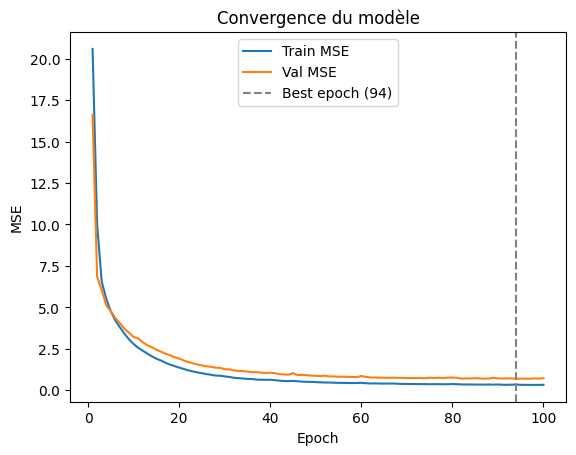

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_mse_history) + 1)

fig, ax = plt.subplots()

ax.plot(epochs, train_mse_history, label='Train MSE')
ax.plot(epochs, val_mse_history, label='Val MSE')
ax.axvline(best_epoch + 1, linestyle='--', color='gray', label=f'Best epoch ({best_epoch+1})')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('Convergence du modèle')
ax.legend()

Text(0.5, 1.0, 'Gap overfitting')

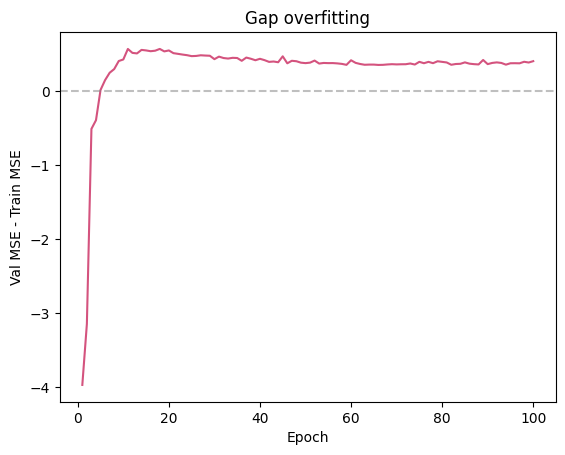

In [ ]:
gap = [v - t for v, t in zip(val_mse_history, train_mse_history)]

fig, ax = plt.subplots()
ax.plot(epochs, gap, color='#D4537E')
ax.axhline(0, linestyle='--', color='gray', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val MSE - Train MSE')
ax.set_title('Gap overfitting')

Modèle AEFARec version SR
Ajout de Fu ⊙ Fi et cos(Fu, Fi) dans l'entrée du MLP

In [ ]:
#  Modèle AEFARec version SR
# Ajout de Fu ⊙ Fi et cos(Fu, Fi) dans l'entrée du MLP

class AEFARecSR(nn.Module):
    def __init__(self, n_users, n_items, k, d=64, hidden=128, p=3):
        super(AEFARecSR, self).__init__()

        # Branche FM — identique à la version papier
        self.user_emb = nn.Embedding(n_users, d)
        self.item_emb = nn.Embedding(n_items, d)
        self.w0 = nn.Parameter(torch.zeros(1))
        self.w_user = nn.Linear(d, 1, bias=False)
        self.w_item = nn.Linear(d, 1, bias=False)

        # Branche MLP => entrée enrichie : Fu ⊕ Fi ⊕ (Fu ⊙ Fi) ⊕ cos(Fu, Fi)
        # 2k + k + 1 = 3k + 1 features en entrée
        layers = []
        input_dim = 3 * k + 1
        for i in range(p):
            in_dim = input_dim if i == 0 else hidden
            layers += [nn.Linear(in_dim, hidden), nn.ReLU()]
        layers.append(nn.Linear(hidden, 1))
        self.mlp = nn.Sequential(*layers)

        # Alpha learnable
        self.alpha = nn.Parameter(torch.tensor(0.5))

    def forward(self, user_ids, item_ids, Fu, Fi):
        # FM
        eu = self.user_emb(user_ids)
        ei = self.item_emb(item_ids)
        linear = self.w0 + self.w_user(eu) + self.w_item(ei)
        interaction = 0.5 * torch.sum(eu * ei, dim=1, keepdim=True)
        yfm = (linear + interaction).squeeze(1)

        # Calcul Fu ⊙ Fi
        fu_fi_interaction = Fu * Fi

        # Calcul cos(Fu, Fi)
        dot = torch.sum(Fu * Fi, dim=1, keepdim=True)
        norm_fu = torch.norm(Fu, dim=1, keepdim=True)
        norm_fi = torch.norm(Fi, dim=1, keepdim=True)
        cosine = dot / (norm_fu * norm_fi + 1e-8)

        # Entrée MLP enrichie
        explicit = torch.cat([Fu, Fi, fu_fi_interaction, cosine], dim=1)
        ymlp = self.mlp(explicit).squeeze(1)

        # Fusion
        alpha = torch.clamp(self.alpha, 0, 1)
        return alpha * yfm + (1 - alpha) * ymlp

In [ ]:
# Entraînement version SR
model_sr = AEFARecSR(n_users, n_items, k, d=64, hidden=128, p=3).to(device)
optimizer_sr = torch.optim.Adam(model_sr.parameters(), lr=0.001, weight_decay=1e-3)

best_val_loss_sr = float('inf')
no_improve_sr = 0

for epoch in range(100):
    # Train
    model_sr.train()
    train_loss = 0
    for user, item, fu, fi, rating in train_loader:
        user, item, fu, fi, rating = [x.to(device) for x in [user, item, fu, fi, rating]]
        optimizer_sr.zero_grad()
        y_hat = model_sr(user, item, fu, fi)
        loss = criterion(y_hat, rating)
        loss.backward()
        optimizer_sr.step()
        train_loss += loss.item()

    # Val
    model_sr.eval()
    val_loss = 0
    with torch.no_grad():
        for user, item, fu, fi, rating in val_loader:
            user, item, fu, fi, rating = [x.to(device) for x in [user, item, fu, fi, rating]]
            y_hat = model_sr(user, item, fu, fi)
            val_loss += criterion(y_hat, rating).item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1:02d} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f} | Alpha: {model_sr.alpha.item():.4f}")

    if val_loss < best_val_loss_sr:
        best_val_loss_sr = val_loss
        torch.save(model_sr.state_dict(), 'best_aefar_sr.pt')
        no_improve_sr = 0
    else:
        no_improve_sr += 1
        if no_improve_sr >= patience:
            print(f"Early stopping à l'epoch {epoch+1}")
            break

In [ ]:
#  Évaluation finale version SR
model_sr.load_state_dict(torch.load('best_aefar_sr.pt'))
model_sr.eval()

preds_sr, targets_sr = [], []
with torch.no_grad():
    for user, item, fu, fi, rating in test_loader:
        user, item, fu, fi, rating = [x.to(device) for x in [user, item, fu, fi, rating]]
        y_hat = model_sr(user, item, fu, fi)
        preds_sr.extend(y_hat.cpu().numpy())
        targets_sr.extend(rating.cpu().numpy())

preds_sr   = torch.tensor(preds_sr)
targets_sr = torch.tensor(targets_sr)

mse_sr = nn.MSELoss()(preds_sr, targets_sr).item()
mae_sr = nn.L1Loss()(preds_sr, targets_sr).item()

print(f"\n── Résultats AEFARec version SR ──")
print(f"Test MSE  : {mse_sr:.4f}")
print(f"Test MAE  : {mae_sr:.4f}")
print(f"Alpha     : {model_sr.alpha.item():.4f}")

print(f"\n── Comparaison ──")
print(f"{'Modèle':<20} {'MSE':>8} {'MAE':>8}")
print(f"{'AEFARec papier':<20} {0.6639:>8.4f} {0.5698:>8.4f}")
print(f"{'AEFARec SR':<20} {mse_sr:>8.4f} {mae_sr:>8.4f}")

Sur le dataset complet (86 378 reviews) la version SR devrait être meilleure
C'est une limitation liée aux contraintes de coût API, pas à la méthode

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import copy

# Valeurs de k à tester (comme sur votre image)
k_values = [5, 6, 7, 8, 9,10,11,12,13,14,15]

# Listes pour stocker les résultats de votre modèle Mistral
mse_results = []
mae_results = []

# Split standard 8:1:1 comme dans le papier
train, temp = train_test_split(final_dataset, test_size=0.2, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

print("Début de l'analyse de l'impact de k...")

for current_k in k_values:
    print(f"\n--- Entraînement pour k = {current_k} ---")

    # 1. Sélectionner uniquement les 'current_k' premiers aspects
    current_T_star = T_star[:current_k]
    fu_cols_k = [f"{a}_user" for a in current_T_star]
    fi_cols_k = [f"{a}_item" for a in current_T_star]

    # 2. Recréer les DataLoaders avec seulement k features explicites
    class DynamicAEFARecDataset(Dataset):
        def __init__(self, df):
            self.user_ids = torch.tensor(df['user_idx'].values, dtype=torch.long)
            self.item_ids = torch.tensor(df['item_idx'].values, dtype=torch.long)
            self.Fu = torch.tensor(df[fu_cols_k].values, dtype=torch.float32)
            self.Fi = torch.tensor(df[fi_cols_k].values, dtype=torch.float32)
            self.ratings = torch.tensor(df['rating'].values, dtype=torch.float32)

        def __len__(self):
            return len(self.ratings)

        def __getitem__(self, idx):
            return (self.user_ids[idx], self.item_ids[idx],
                    self.Fu[idx], self.Fi[idx], self.ratings[idx])

    train_loader_k = DataLoader(DynamicAEFARecDataset(train), batch_size=256, shuffle=True)
    val_loader_k   = DataLoader(DynamicAEFARecDataset(val),   batch_size=256)
    test_loader_k  = DataLoader(DynamicAEFARecDataset(test),  batch_size=256)

    # 3. Initialiser le modèle avec la bonne dimension k
    model_k = AEFARec(n_users, n_items, k=current_k, d=64, hidden=128, p=3).to(device)
    optimizer_k = torch.optim.Adam(model_k.parameters(), lr=0.001, weight_decay=1e-3)
    criterion_k = nn.MSELoss()

    best_val_loss = float('inf')
    patience = 10
    no_improve = 0
    best_model_state = None

    # 4. Boucle d'entraînement rapide
    for epoch in range(50): # Limité à 50 pour accélérer
        model_k.train()
        for user, item, fu, fi, rating in train_loader_k:
            user, item, fu, fi, rating = [x.to(device) for x in [user, item, fu, fi, rating]]
            optimizer_k.zero_grad()
            y_hat = model_k(user, item, fu, fi)
            loss = criterion_k(y_hat, rating)
            loss.backward()
            optimizer_k.step()

        # Validation
        model_k.eval()
        val_loss = 0
        with torch.no_grad():
            for user, item, fu, fi, rating in val_loader_k:
                user, item, fu, fi, rating = [x.to(device) for x in [user, item, fu, fi, rating]]
                y_hat = model_k(user, item, fu, fi)
                val_loss += criterion_k(y_hat, rating).item()

        val_loss /= len(val_loader_k)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model_k.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    # 5. Évaluation sur le Test Set avec le meilleur modèle pour ce k
    model_k.load_state_dict(best_model_state)
    model_k.eval()
    preds, targets = [], []
    with torch.no_grad():
        for user, item, fu, fi, rating in test_loader_k:
            user, item, fu, fi, rating = [x.to(device) for x in [user, item, fu, fi, rating]]
            y_hat = model_k(user, item, fu, fi)
            preds.extend(y_hat.cpu().numpy())
            targets.extend(rating.cpu().numpy())

    preds = torch.tensor(preds)
    targets = torch.tensor(targets)

    test_mse = nn.MSELoss()(preds, targets).item()
    test_mae = nn.L1Loss()(preds, targets).item()

    print(f"Résultat final pour k={current_k} -> MSE: {test_mse:.4f}, MAE: {test_mae:.4f}")

    # Sauvegarder les résultats
    mse_results.append(test_mse)
    mae_results.append(test_mae)

In [ ]:
import matplotlib.pyplot as plt

# Configuration du style global pour correspondre à l'image
plt.rcParams.update({
    'font.size': 14,
    'axes.grid': True,
    'grid.linestyle': '-',
    'grid.alpha': 0.7
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphique 1 : MSE ---
# J'utilise 'Mistral' comme label puisque c'est votre LLM,
# mais vous pouvez ajouter une autre courbe si vous voulez comparer avec un autre modèle.
ax1.plot(k_values, mse_results, marker='o', markersize=5, linestyle='-', color='#ff7f0e', label='Mistral')

ax1.set_xlabel('k', fontweight='bold')
ax1.set_ylabel('MSE', fontweight='bold')
ax1.set_xticks(k_values)
# Ajout d'une grille secondaire en pointillé si besoin
ax1.grid(True, which='major', linestyle='-')
ax1.grid(True, which='minor', linestyle=':', alpha=0.5)
ax1.legend(fontsize=14)

# --- Graphique 2 : MAE ---
ax2.plot(k_values, mae_results, marker='o', markersize=5, linestyle='-', color='#ff7f0e', label='Mistral')

ax2.set_xlabel('k', fontweight='bold')
ax2.set_ylabel('MAE', fontweight='bold')
ax2.set_xticks(k_values)
ax2.grid(True, which='major', linestyle='-')
ax2.legend(fontsize=14)

# Ajustement de l'espacement et affichage
plt.tight_layout()
plt.show()

In [ ]:
"""##6. Diversification des recommandations (Personne 5)

Objectif : éviter les listes Top-K trop redondantes en ajoutant une étape
de re-ranking en fin de pipeline, inspirée du compromis pertinence / diversité
(article "Adaptive diversification of recommendation results").

On reprend uniquement l'idée principale, pas toute la méthode LFP.
Formule simplifiée appliquée après la prédiction des scores par AEFARec-SR :

    ScoreFinal(i) = λ · ScorePertinence(i) − (1 − λ) · max_{j ∈ S} sim(i, j)

avec :
- ScorePertinence(i) = rating prédit par AEFARec-SR
- sim(i, j)          = similarité cosinus entre les vecteurs Fi des items i et j
- S                  = liste des items déjà sélectionnés
- λ ∈ [0, 1]         = compromis (1 = pertinence pure, 0 = diversité pure)

C'est une version greedy de type MMR (Maximal Marginal Relevance).
Elle reste légère et se branche directement sur le modèle déjà entraîné.
"""

import numpy as np
import pandas as pd
import torch

# On réutilise le modèle AEFARec-SR déjà entraîné
model_sr.eval()

# Construction d'une matrice Fu alignée sur user_idx et d'une matrice Fi alignée sur item_idx
# (les valeurs sont déjà normalisées dans final_dataset, donc on se contente de la moyenne)
k_aspects = len(T_star)

Fi_matrix = (
    final_dataset.groupby('item_idx')[fi_cols]
    .mean()
    .reindex(range(n_items), fill_value=0.0)
    .values.astype(np.float32)
)

Fu_matrix = (
    final_dataset.groupby('user_idx')[fu_cols]
    .mean()
    .reindex(range(n_users), fill_value=0.0)
    .values.astype(np.float32)
)

# Pré-calcul : pour chaque utilisateur, les items déjà notés (à exclure des recommandations)
user_to_seen = (
    final_dataset.groupby('user_idx')['item_idx']
    .apply(set)
    .to_dict()
)


def predict_scores_for_user(user_idx, candidate_items):
    """Prédit le rating pour un utilisateur et une liste d'items candidats."""
    u = torch.full((len(candidate_items),), user_idx, dtype=torch.long, device=device)
    i = torch.tensor(candidate_items, dtype=torch.long, device=device)
    fu_vec = torch.tensor(Fu_matrix[user_idx], dtype=torch.float32, device=device)
    fu = fu_vec.unsqueeze(0).expand(len(candidate_items), -1)
    fi = torch.tensor(Fi_matrix[candidate_items], dtype=torch.float32, device=device)
    with torch.no_grad():
        y_hat = model_sr(u, i, fu, fi)
    return y_hat.cpu().numpy()


def cosine_sim_items(i, j):
    """Similarité cosinus entre deux items via leur vecteur Fi."""
    vi, vj = Fi_matrix[i], Fi_matrix[j]
    denom = (np.linalg.norm(vi) + 1e-8) * (np.linalg.norm(vj) + 1e-8)
    return float(np.dot(vi, vj) / denom)


def mmr_rerank(scores, candidate_items, K=10, lam=0.7):
    """Re-ranking greedy de type MMR.

    scores          : np.array, scores de pertinence des candidats
    candidate_items : liste d'item_idx
    K               : taille de la liste finale
    lam             : poids de la pertinence (1 - lam = poids de la diversité)
    """
    # Normalisation min-max pour comparer scores et similarités sur une même échelle
    s_min, s_max = float(scores.min()), float(scores.max())
    if s_max > s_min:
        scores_norm = (scores - s_min) / (s_max - s_min)
    else:
        scores_norm = np.zeros_like(scores)

    remaining = list(range(len(candidate_items)))
    # Premier item = le plus pertinent (aucune diversité à pénaliser encore)
    first = int(np.argmax(scores_norm))
    selected = [first]
    remaining.remove(first)

    while len(selected) < K and remaining:
        best_idx, best_score = None, -np.inf
        for c in remaining:
            item_c = candidate_items[c]
            max_sim = max(
                cosine_sim_items(item_c, candidate_items[s]) for s in selected
            )
            final_score = lam * scores_norm[c] - (1 - lam) * max_sim
            if final_score > best_score:
                best_score, best_idx = final_score, c
        selected.append(best_idx)
        remaining.remove(best_idx)

    return [candidate_items[s] for s in selected]


def intra_list_diversity(items):
    """ILD = moyenne des (1 - cos_sim) sur toutes les paires d'items de la liste."""
    if len(items) < 2:
        return 0.0
    diffs = [
        1.0 - cosine_sim_items(items[a], items[b])
        for a in range(len(items))
        for b in range(a + 1, len(items))
    ]
    return float(np.mean(diffs))

In [ ]:
# Expérimentation : impact de λ sur pertinence moyenne et diversité
N_CANDIDATES = 50          # on ne ré-ordonne que les 50 meilleurs candidats
K_TOP = 10                 # taille finale de la liste recommandée
N_USERS_SAMPLE = 100       # échantillon pour éviter de parcourir tous les utilisateurs

rng = np.random.default_rng(42)
sample_users = rng.choice(n_users, size=min(N_USERS_SAMPLE, n_users), replace=False)

lambda_values = [1.0, 0.9, 0.7, 0.5, 0.3]
results_div = []
all_item_idx = np.arange(n_items)

for lam in lambda_values:
    ilds, avg_scores = [], []

    for u in sample_users:
        seen = user_to_seen.get(int(u), set())
        unseen = np.array([i for i in all_item_idx if i not in seen])

        scores = predict_scores_for_user(int(u), unseen)

        # Étape 1 : on garde les N_CANDIDATES items avec le meilleur rating prédit
        top_candidates_idx = np.argsort(-scores)[:N_CANDIDATES]
        cand_items = unseen[top_candidates_idx]
        cand_scores = scores[top_candidates_idx]

        # Étape 2 : re-ranking MMR pour construire la liste finale
        selected = mmr_rerank(cand_scores, cand_items.tolist(), K=K_TOP, lam=lam)

        item_to_score = dict(zip(cand_items.tolist(), cand_scores.tolist()))
        sel_scores = [item_to_score[it] for it in selected]

        ilds.append(intra_list_diversity(selected))
        avg_scores.append(float(np.mean(sel_scores)))

    results_div.append({
        'lambda': lam,
        'avg_predicted_rating': float(np.mean(avg_scores)),
        'ILD': float(np.mean(ilds)),
    })

df_div = pd.DataFrame(results_div)

print("\n── Impact de la diversification (Personne 5) ──")
print(df_div.round(4).to_string(index=False))
print("""
Lecture :
- λ = 1.0 : recommandation classique par score (pas de diversification)
- λ plus petit : on sacrifie un peu de rating prédit pour gagner en diversité (ILD ↑)
- ILD = 0 : liste totalement redondante / ILD proche de 1 : liste très variée.
""")

In [ ]:
# Exemple concret sur un utilisateur (utile pour l'oral)
example_user = int(sample_users[0])
seen = user_to_seen.get(example_user, set())
unseen = np.array([i for i in all_item_idx if i not in seen])
scores_ex = predict_scores_for_user(example_user, unseen)
top_idx = np.argsort(-scores_ex)[:N_CANDIDATES]
cand_items_ex = unseen[top_idx]
cand_scores_ex = scores_ex[top_idx]

top_no_div = mmr_rerank(cand_scores_ex, cand_items_ex.tolist(), K=K_TOP, lam=1.0)
top_with_div = mmr_rerank(cand_scores_ex, cand_items_ex.tolist(), K=K_TOP, lam=0.7)

asin_by_idx = dict(zip(final_dataset['item_idx'], final_dataset['parent_asin']))

print(f"\nExemple pour user_idx={example_user} "
      f"(user_id={user_encoder.inverse_transform([example_user])[0]}) :")
print("  Top-10 sans diversification (λ=1.0) :")
for rank, it in enumerate(top_no_div, 1):
    print(f"    {rank:>2}. {asin_by_idx.get(it, '?')}  score={cand_scores_ex[np.where(cand_items_ex == it)[0][0]]:.3f}")
print(f"    ILD = {intra_list_diversity(top_no_div):.3f}")

print("\n  Top-10 avec diversification (λ=0.7) :")
for rank, it in enumerate(top_with_div, 1):
    print(f"    {rank:>2}. {asin_by_idx.get(it, '?')}  score={cand_scores_ex[np.where(cand_items_ex == it)[0][0]]:.3f}")
print(f"    ILD = {intra_list_diversity(top_with_div):.3f}")

# Graphique : compromis pertinence / diversité
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_xlabel('λ (poids de la pertinence)', fontweight='bold')
ax1.set_ylabel('Rating prédit moyen (Top-10)', color='tab:blue', fontweight='bold')
ax1.plot(df_div['lambda'], df_div['avg_predicted_rating'],
         marker='o', color='tab:blue', label='Pertinence moyenne')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.invert_xaxis()  # λ=1 à gauche (pertinence seule), λ=0.3 à droite (plus divers)

ax2 = ax1.twinx()
ax2.set_ylabel('Intra-List Diversity (ILD)', color='tab:red', fontweight='bold')
ax2.plot(df_div['lambda'], df_div['ILD'],
         marker='s', color='tab:red', label='Diversité (ILD)')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Compromis pertinence / diversité — re-ranking MMR')
fig.tight_layout()
plt.show()